**Note**

Here is the list of files necessary for the pratical course:

```
.
├── Docking_analysis_Student.ipynb
├── banque
│   ├── ligand_0001.pdbqt
|   ├── ligand_0002.pdbqt
│   .   .................
│   └── ligand_0050.pdbqt
|
└── trajectories
    ├── 1FVV_em.gro
    ├── 1FVV_prod.xtc
    ├── 1FVV_lig_em.gro
    ├── 1FVV_lig_prod.xtc
    ├── 3PXR_em.gro 
    └── 3PXR_prod.xtc
```

Be sure to have all this files before starting the pratical work.

You need to use a specific conda environment given by the instructor.

    conda activate smurail-openmm_course-25


Or you can use the given `.yml` file to create the environment :

    conda env create -f .conda.yml
    conda activate vina_MD


In [1]:
import sys
import os
import urllib.request
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import MDAnalysis as mda

In [2]:
%matplotlib inline

# Virtual screening using MD simulation

*Samuel Murail (inspired by a pratical work from Maxime Louet, université de Montpellier)*

## Goal

This lab work aims to understand the dynamic complexity of a protein and especially a pocket that can bind one or more ligands. The aim will be to evaluate rigid docking technique, via the **Vina** software, on several protein structures obtain from X-ray diffraction or molecular dynamics (MD) simulation. The example presented will be that of the CDK2 protein.

## CDK2

Cyclin-dependent kinases (CDKs) are a family of protein kinases that have a major role in cell cycle regulation. They are also involved in the regulating transcription, mRNA processing, and the differentiation of nerve cells. They are present in all eukaryotes and their function in the cell cycle has been very conserved during evolution, yeasts can survive and proliferate normally if their genes encoding CDKs have been replaced by their human counterparts. CDKs proteins phosphorylate their substrates on serines and threonines, making them serine-threonine kinases. 

*sources:* https://en.wikipedia.org/wiki/Cyclin-dependent_kinase

## Crystal structures

The crystalline structure, resolved by X-ray diffraction, of the CDK2 protein is known and stored
in the Protein Data Bank (PDB: http://www.rcsb.org). Its structure is known alone (apo form of the protein, PDB id: [**3PXR**](https://www.rcsb.org/structure/3PXR) or linked to an inhibitor (holo form of the protein, PDB id: [1FVV](https://www.rcsb.org/structure/1FVV). 

First we will download and display their structures:

### Get PDB file from the `rcsb.org`website

In [3]:
# Setup data location
DATA_OUT = 'data_sim'
PDB_IN = 'pdb'
PDB_list = ['3PXR', '1FVV']

os.makedirs(PDB_IN, exist_ok = True)

for pdb_id in PDB_list:
    raw_pdb = urllib.request.urlretrieve('http://files.rcsb.org/download/{}.pdb'.format(pdb_id),
                                         '{}/{}.pdb'.format(PDB_IN, pdb_id))

### Align the two proteins

To align the two structures we will use the `MDAnalysis` library. Follow the [link](https://www.mdanalysis.org/pages/basic_example/) to have a basic example of `MDAnalysis` library.

- Create 2 `MDAnalysis` object using the `Universe` function.
- Use the `align.alignto` function to align one on the other structure. [**See**](https://www.mdanalysis.org/docs/documentation_pages/analysis/align.html) 
    - You will need to define a selection of atoms for the alignment, use it as the argument `select` in the align function. `align.alignto(u_1, u_ref_pdb, select='...')
    - Use the holo structure as reference structure for the alignment
    - you can use different keywords to select the atoms(`protein`, `name` for atom name, `segid` for chain, and `resid x:y` to select residue x to y).
    - The selection should contains the same number of atoms in both structure.
    - Be carefull some residues are missing in one of the structure.
- Eventually use the `write` function to save align coordinates of protein **chain A** in the `PDB_IN` directory. 
- Extract ligand strutcure of **chain A** alone and save it.

<span style='color:red'>Q1:</span>

In [4]:
from MDAnalysis.analysis import align

apo = mda.Universe('{}/{}.pdb'.format(PDB_IN, PDB_list[0]))
holo = mda.Universe('{}/{}.pdb'.format(PDB_IN, PDB_list[1]))

align.alignto(apo, holo, select="protein and name CA and segid A and not resid 36:41", weights="mass")

apo_prot = apo.select_atoms('protein and segid A')
holo_prot = holo.select_atoms('protein and segid A')
holo_prot_lig = holo.select_atoms('(protein or resname 107) and segid A')
holo_lig = holo.select_atoms('resname 107 and segid A')

apo_prot.write("{}/{}_chain_A.pdb".format(PDB_IN, PDB_list[0]))
holo_prot.write("{}/{}_chain_A.pdb".format(PDB_IN, PDB_list[1]))
holo_prot_lig.write("{}/{}_lig_chain_A.pdb".format(PDB_IN, PDB_list[1]))
holo_lig.write("{}/{}_lig.pdb".format(PDB_IN, PDB_list[1]))

/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(
/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"


### Extact pocket residues

Define a selection of protein residues around 5 Å of the ligand and get their residue number.
You can access the residue number of `MDAnalysis` object using the attribute `mda_selection.residues.resids`.
Save the residue list in a list named `residue_list`.

<span style='color:red'>Q2:</span>

In [41]:
residue_list = []
mda_selection = holo.select_atoms('protein and around 5 resname 107')
for resid in mda_selection.residues.resids:
    residue_list.append(resid)
print(residue_list)

[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(18), np.int64(31), np.int64(33), np.int64(51), np.int64(64), np.int64(80), np.int64(81), np.int64(82), np.int64(83), np.int64(84), np.int64(85), np.int64(86), np.int64(89), np.int64(134), np.int64(144), np.int64(145), np.int64(8), np.int64(9), np.int64(10), np.int64(18), np.int64(31), np.int64(33), np.int64(51), np.int64(64), np.int64(80), np.int64(81), np.int64(82), np.int64(83), np.int64(84), np.int64(85), np.int64(86), np.int64(89), np.int64(134), np.int64(144), np.int64(145), np.int64(298)]


### Visualise the 2 structures:

Use the `py3Dmol` library to visualize the two align structures. You may need to update the pdb path and name.

In [20]:
import py3Dmol

res_show_list = [int(i) for i in residue_list]

model_1 = open('pdb/3PXR_chain_A.pdb', 'r').read()
model_2 = open('pdb/1FVV_lig_chain_A.pdb', 'r').read()

view = py3Dmol.view()
view.addModel(model_1, 'pdb')
view.setStyle({'model': -1}, {'cartoon': {'color':'red'}})
view.addStyle({'model': -1, 'resi': res_show_list},
              {'stick':{'radius': 0.4, 'color':'red'}})
view.addModel(model_2, 'pdb')
view.setStyle({'model': -1}, {'cartoon': {'color':'blue'}})
view.addStyle({'model': -1, 'resi': res_show_list}, 
              {'stick':{'radius': 0.4, 'color':'blue'}})
view.addStyle({'resn': '107'}, {'sphere': {'radius': 1.5}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Visualize ligand crystal density

You can check the ligand coordinates and the fit in the electron density in the EMBL-EBI pdb2 website :
- https://www.ebi.ac.uk/pdbe/entry/pdb/1fvv/bound/107

<span style='color:red'>Q3:</span> Discuss it.

## Ligand parametrisation for MD

- Get ligand coordinates from `1FVV` PDBID. 
- Add hydrogens using Rdkit
- Vizualise it using `nglview`

In [21]:
from rdkit import Chem
from rdkit.Chem import AllChem
import nglview as nv

# Create molecule from smile:
ref_lig = Chem.MolFromSmiles('O=S(=O)(Nc1ncccc1)c2ccc(cc2)NCC=5C(=O)N=C4C=5c3scnc3C=C4')
# Read pdb
ligand = Chem.MolFromPDBFile('pdb/1FVV_lig.pdb')

# assign bond order from smile to the ligand object
ligand = AllChem.AssignBondOrdersFromTemplate(ref_lig, ligand)
# Add hydrogens
ligand = Chem.AddHs(ligand, addCoords=True, addResidueInfo=True)

# Save pdb
Chem.MolToPDBFile(ligand, './pdb/oxindole_inhibitor.pdb', flavor=2)

# Visualise ligand with hydrogens
view = nv.show_rdkit(ligand)
view

[15:04:09] WARNING: More than one matching pattern found - picking one



NGLWidget()

## MD simulations

Here is the list of MD files:

```
.
└── trajectories
    ├── 1FVV_em.gro
    ├── 1FVV_prod.xtc
    ├── 1FVV_lig_em.gro
    ├── 1FVV_lig_prod.xtc
    ├── 3PXR_em.gro 
    └── 3PXR_prod.xtc
```

A set of three trajectories (computed by myself) :
 - 500 ns simulation of 1FVV alone (`1FVV_em.gro` and `1FVV_prod.xtc`).
 - 500 ns simulation of 1FVV with its ligand (`1FVV_lig_em.gro` and `1FVV_lig_prod.xtc`).
 - 500 ns simulation of 3PXR (`3PXR_em.gro` and `3PXR_prod.xtc`).

Protein Data Bank IDs **1FVV** and **3PXR** have been used as starting structures. The charmm36m forcefield has been used for protein and ions, as TIP3P model was used to model water molecules. The [CGENFF Webserver](https://cgenff.umaryland.edu) was used to obtain oxindole inhibitor parameters.

All three systems have been minimized for 2000 steps using steepest descent algorithm followed by three successive equilibrations : (*i*) 0.25 ns using position restraints of 1000 $KJ.mol^{-1}.nm^{-2}$ on all heavy atoms, (*ii*) 1ns using position restraints of 1000 $KJ.mol^{-1}.nm^{-2}$ on $C_{\alpha}$ atoms (*iii*) 5ns using position restraints of 100 $KJ.mol^{-1}.nm^{-2}$ on $C_{\alpha}$ atoms. Production run were computed for 500 ns without any position restraints.

## Visualize MD 1FVV+ligand simulation

In [22]:
# Read simulation
holo_lig_md = mda.Universe('trajectories/1FVV_lig_em.gro', 'trajectories/1FVV_lig_prod.xtc')

# Align simulation on C aplha atoms
alignment = align.AlignTraj(holo_lig_md,
                            holo_prot,
                            select='name CA and protein',
                            in_memory=True,
                            verbose=True)
alignment.run()

/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/coordinates/XDR.py:253: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(


  0%|          | 0/2001 [00:00<?, ?it/s]

In [24]:
view = nv.show_mdanalysis(holo_lig_md.select_atoms('not name H* M*'), gui=True)

view.clear()

view.camera = 'orthographic'
view.add_cartoon('protein')
view.add_licorice(" ".join([str(i) for i in residue_list]))
view.add_representation('spacefill', selection='not protein', component=0)

view

NGLWidget(max_frame=2000)

- <span style='color:red'>Q4:</span> What can you observe in the simulation concerning the ligand position:


- <span style='color:red'>Q5:</span> Give some explanations or insights :

- <span style='color:red'>Q6:</span> Look in the three MD simulation which pocket residues display very high drift, it may be wise to remove them from the residue selection use later for alignment. Discuss it.



Q4: In the simulation we observe that while the residues around the ligand in the internal protein pocket, stay relatively in the same position, and only change their conformation, there are other residues (Leu298 at the Cter of the protein) drifts away from the ligand during the course of MD simulation.
Q5: This is happaning due to ??? unbound free cter, a lot of wiggle, no structure
Q6: 

## Define the pocket residue for alignement

- <span style='color:red'>Q7:</span> Remove residues from the list `residue_list` which are involve in high drift and save them in the list `residue_list_sel`.


In [44]:
residue_list

[np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(18),
 np.int64(31),
 np.int64(33),
 np.int64(51),
 np.int64(64),
 np.int64(80),
 np.int64(81),
 np.int64(82),
 np.int64(83),
 np.int64(84),
 np.int64(85),
 np.int64(86),
 np.int64(89),
 np.int64(134),
 np.int64(144),
 np.int64(145),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(18),
 np.int64(31),
 np.int64(33),
 np.int64(51),
 np.int64(64),
 np.int64(80),
 np.int64(81),
 np.int64(82),
 np.int64(83),
 np.int64(84),
 np.int64(85),
 np.int64(86),
 np.int64(89),
 np.int64(134),
 np.int64(144),
 np.int64(145),
 np.int64(298)]

In [47]:
residue_list_sel = [int(i) for i in residue_list]
residue_list_remove = [298]
for res in residue_list_remove:
    residue_list_sel.remove(res)
residue_list_sel

[8,
 9,
 10,
 11,
 18,
 31,
 33,
 51,
 64,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 89,
 134,
 144,
 145,
 8,
 9,
 10,
 18,
 31,
 33,
 51,
 64,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 89,
 134,
 144,
 145]

## Align all trajetories on pocket residues and save it

Load and align the 3 MD simulation on the previously defined pocket residues.
Call the three `mda.Universe()` objects `holo_lig_md`, `holo_md` and `apo_md`.

- Use the holo structure as reference
- **Caution** alway use the same reference structure for the alignments.
- Later we will load all trajectories in one, so save **also** the trajectories with the same atom number for the 3 systems (*eg.* pocket residues)

After trajectory alignment save the trajectories using this procedure as example:
```
# Save pocket coordinates
holo_lig_pocket = holo_lig_md.select_atoms('not name H* M* and resid {}'.format(" ".join(str(x) for x in residue_list_sel)))                    
holo_lig_pocket.write('trajectories/pocket_1FVV_lig_prod.pdb')
                              
with mda.Writer('trajectories/pocket_1FVV_lig_prod.xtc', holo_lig_pocket.n_atoms) as W:
    for ts in holo_lig_md.trajectory:
        W.write(holo_lig_pocket)
```

- Save the coordinqtes and trajectories as `trajectories/pocket_3PXR_prod.pdb` `trajectories/pocket_3PXR_prod.xtc`, `trajectories/pocket_1FVV_prod.pdb` `trajectories/pocket_1FVV_prod.xtc`, `trajectories/pocket_1FVV_lig_prod.pdb`, `trajectories/pocket_1FVV_lig_prod.xtc`.

<span style='color:red'>Q8:</span>


In [48]:
apo_md = mda.Universe('trajectories/3PXR_em.gro', 'trajectories/3PXR_prod.xtc')
print("Number of frame =", len(apo_md.trajectory))

#ref_prot = ref.select_atoms('protein')
alignment = align.AlignTraj(apo_md,
                            holo_prot,
                            select='name CA and resid {}'.format(" ".join(str(x) for x in residue_list_sel)),
                            in_memory=True,
                            verbose=True)
alignment.run()

holo_md = mda.Universe('trajectories/1FVV_em.gro', 'trajectories/1FVV_prod.xtc')
print("Number of frame =", len(holo_md.trajectory))

#ref_prot = ref.select_atoms('protein')
alignment = align.AlignTraj(holo_md,
                            holo_prot,
                            select='name CA and resid {}'.format(" ".join(str(x) for x in residue_list_sel)),
                            in_memory=True,
                            verbose=True)
alignment.run()

holo_lig_md = mda.Universe('trajectories/1FVV_lig_em.gro', 'trajectories/1FVV_lig_prod.xtc')
print("Number of frame =", len(holo_lig_md.trajectory))

#ref_prot = ref.select_atoms('protein')
alignment = align.AlignTraj(holo_lig_md,
                            holo_prot,
                            select='name CA and resid {}'.format(" ".join(str(x) for x in residue_list_sel)),
                            in_memory=True,
                            verbose=True)
alignment.run()

Number of frame = 2001


  0%|          | 0/2001 [00:00<?, ?it/s]

Number of frame = 2001


  0%|          | 0/2001 [00:00<?, ?it/s]

Number of frame = 2001


  0%|          | 0/2001 [00:00<?, ?it/s]

In [49]:
residue_list_sel

[8,
 9,
 10,
 11,
 18,
 31,
 33,
 51,
 64,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 89,
 134,
 144,
 145,
 8,
 9,
 10,
 18,
 31,
 33,
 51,
 64,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 89,
 134,
 144,
 145]

In [50]:
# Save pocket coordinates
holo_lig_pocket = holo_lig_md.select_atoms('not name H* M* and resid {}'.format(" ".join(str(x) for x in residue_list_sel)))                    
holo_lig_pocket.write('trajectories/pocket_1FVV_lig_prod.pdb')
                              
with mda.Writer('trajectories/pocket_1FVV_lig_prod.xtc', holo_lig_pocket.n_atoms) as W:
    for ts in holo_lig_md.trajectory:
        W.write(holo_lig_pocket)
        
apo_pocket = apo_md.select_atoms('not name H* M* and resid {}'.format(" ".join(str(x) for x in residue_list_sel)))                    
apo_pocket.write('trajectories/pocket_3PXR_prod.pdb')

with mda.Writer('trajectories/pocket_3PXR_prod.xtc', apo_pocket.n_atoms) as W:
    for ts in apo_md.trajectory:
        W.write(apo_pocket)

holo_pocket = holo_md.select_atoms('not name H* M* and resid {}'.format(" ".join(str(x) for x in residue_list_sel)))                    
holo_pocket.write('trajectories/pocket_1FVV_prod.pdb')
                              
with mda.Writer('trajectories/pocket_1FVV_prod.xtc', holo_pocket.n_atoms) as W:
    for ts in holo_md.trajectory:
        W.write(holo_pocket)


/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'chainIDs' Using default value of ''
  warnings.warn("Found no information for attr: '{}'"
/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn("Found no information for attr: '{}'"
/opt/sdv/minico

## PCA

- To cluster the trajectories we will use a PCA.
- Create a `MDAnalysis` object containing all pocket trajectories and the crystal structures

In [51]:
import MDAnalysis.analysis.pca as pca

# The first pdb is only used for topologie,
# To read the crystal coordinates, put it in first and 2nd place

all_sim = mda.Universe('trajectories/pocket_1FVV_lig_prod.pdb',
                       'trajectories/pocket_1FVV_lig_prod.pdb',
                       'trajectories/pocket_3PXR_prod.pdb',
                       'trajectories/pocket_3PXR_prod.xtc',
                       'trajectories/pocket_1FVV_prod.xtc',
                       'trajectories/pocket_1FVV_lig_prod.xtc')

/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/coordinates/XDR.py:253: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(
/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/coordinates/base.py:728: UserWarning: Reader has no dt information, set to 1.0 ps
  return self.ts.dt


In [52]:
view = nv.show_mdanalysis(all_sim, gui=True)

view.clear()

view.camera = 'orthographic'
view.add_cartoon('protein')
view.add_licorice(" ".join([str(i) for i in residue_list]))
view.add_representation('spacefill', selection='not protein', component=0)

view

NGLWidget(max_frame=6004)

- run the PCA:

In [53]:
prot_pca = pca.PCA(all_sim, select='all')
prot_pca.run()

/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/analysis/base.py:542: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time


- pca variance:

/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/analysis/pca.py:370: DeprecationWarning: The `cumulated_variance` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.cumulated_variance` instead.
  warnings.warn(wmsg, DeprecationWarning)


(0.0, 1.0)

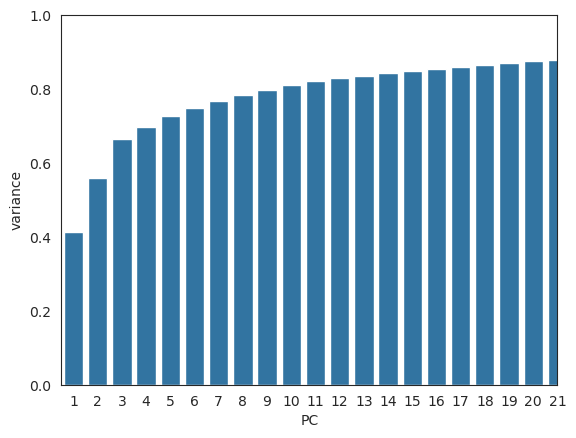

In [54]:
# Get components defining 95 % of variance
n_pcs = np.where(prot_pca.cumulated_variance > 0.95)[0][0]


variance_pd = pd.DataFrame(prot_pca.cumulated_variance, columns=['variance'] )
variance_pd['PC']=range(1,len(prot_pca.cumulated_variance)+1)
variance_pd['PC']=variance_pd['PC']

plt.figure()
ax = sns.barplot(data=variance_pd, x='PC', y='variance')
plt.xlim(-0.5,20)
plt.ylim(0,1.0)

- <span style='color:red'>Q9:</span> Discuss the variance ...



- Store pca results in a `pandas` data frame:

In [55]:
pc_num = 6
atomgroup = all_sim.select_atoms('protein')

pca_space = prot_pca.transform(atomgroup, n_components=pc_num)

col_names = ['PC_{}'.format(i+1) for i in range(pc_num)]
pca_df = pd.DataFrame(pca_space, columns=col_names)


sim_list = ['1FVV_cryst', '3PXR_cryst', '3PXR_sim', '1FVV_sim', '1FVV_lig_sim']
frame_num_list = [1, 1, 2001, 2001, 2001]

label_list = []
frame_num = []
for i, label in enumerate(sim_list):
    label_list += frame_num_list[i] * [label]
    frame_num += list(range(frame_num_list[i]))

pca_df['sim'] = label_list
pca_df['frame'] = frame_num
pca_df.head()

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,sim,frame
0,-11.102520,3.172165,3.470976,-3.583384,-0.982904,-5.508179,1FVV_cryst,0
1,10.623946,4.029505,-10.819025,3.200073,2.027048,6.079594,3PXR_cryst,0
2,10.627930,4.028366,-10.823509,3.200412,2.027659,6.081722,3PXR_sim,0
3,11.878248,6.762733,-7.712154,-1.878705,2.530926,6.764893,3PXR_sim,1
4,14.113789,3.863351,-4.470414,-1.397589,1.162624,4.469471,3PXR_sim,2


- plot density plot and add crystal structures as reference:

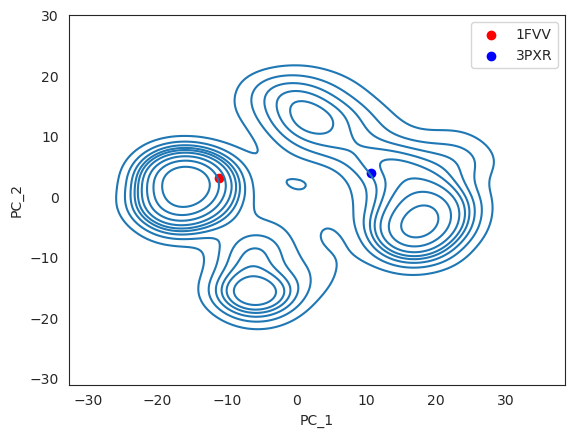

In [56]:
plt.figure()
sns.set_style("white")
sns.kdeplot(data=pca_df, x="PC_1", y="PC_2")
plt.scatter(pca_df.PC_1[0], pca_df.PC_2[0], color='red', label='1FVV')
plt.scatter(pca_df.PC_1[1], pca_df.PC_2[1], color='blue', label='3PXR')
plt.legend()

- plot pca projection as function of simulations:

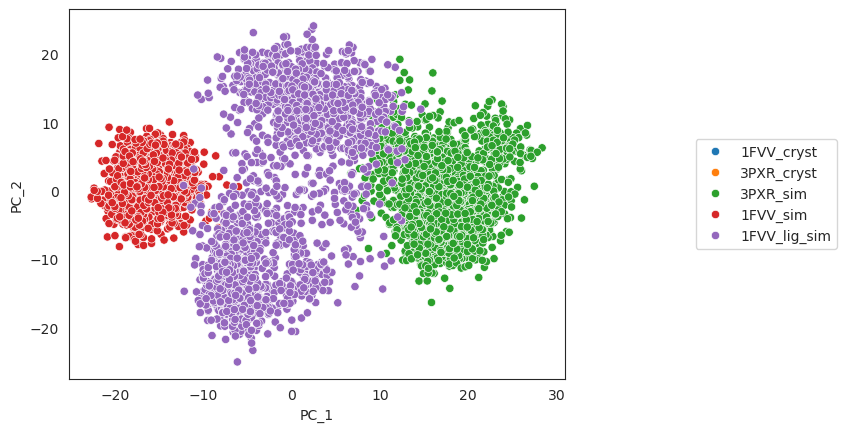

In [57]:
plt.figure()
ax = sns.scatterplot(x="PC_1", y="PC_2", hue="sim",
                     data=pca_df)

ax.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), ncol=1)

- <span style='color:red'>Q10:</span> Discuss the pocket PCA.
- <span style='color:red'>Q11:</span> Does it seem to be any convergence of MD simulations ?
- <span style='color:red'>Q12:</span> Does the MD simulations sample enought the pocket structure ?
- <span style='color:red'>Q13:</span> In an ideal world how MD simulations should be redone ?

## Clustering

We will now cluster the pocket structures obtain from MD simulations using the DBSCAN algorithm.

Here is a video ahowing how DBSCAN works:

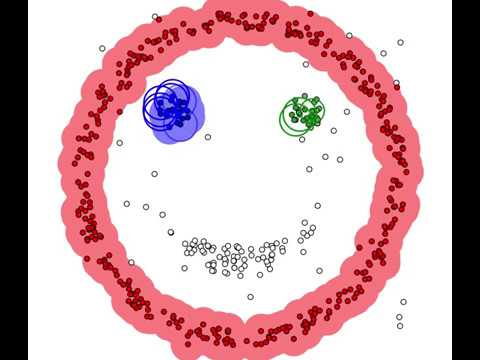

In [58]:
from IPython.lib.display import YouTubeVideo
YouTubeVideo('h53WMIImUuc')

In [59]:
from sklearn.cluster import DBSCAN

clustering = DBSCAN(eps=4, min_samples=70).fit(pca_df[['PC_1', 'PC_2', 'PC_3', 'PC_4']])
labels = clustering.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print('Number of cluster : {}, perc of non clustered points : {:.1f}%'.format(n_clusters_, 100*n_noise_/len(pca_df)))
pca_df['clust']=labels


Number of cluster : 4, perc of non clustered points : 14.2%


In [60]:
pca_df.head()

,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,sim,frame,clust
0,-11.102520,3.172165,3.470976,-3.583384,-0.982904,-5.508179,1FVV_cryst,0,1
1,10.623946,4.029505,-10.819025,3.200073,2.027048,6.079594,3PXR_cryst,0,0
2,10.627930,4.028366,-10.823509,3.200412,2.027659,6.081722,3PXR_sim,0,0
3,11.878248,6.762733,-7.712154,-1.878705,2.530926,6.764893,3PXR_sim,1,0
4,14.113789,3.863351,-4.470414,-1.397589,1.162624,4.469471,3PXR_sim,2,0


- display the clusters:

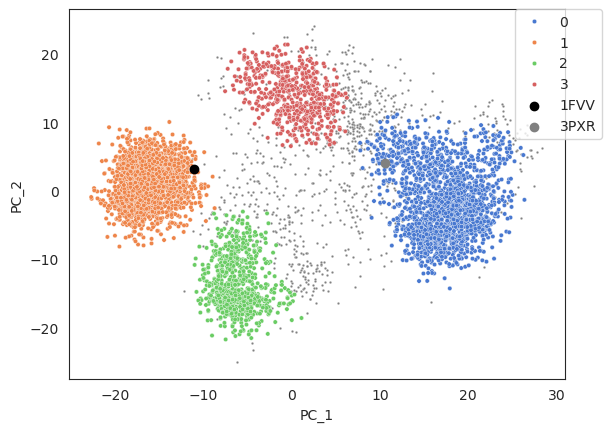

In [61]:
plt.figure()
sns.scatterplot(data=pca_df[pca_df.clust<0], x="PC_1", y="PC_2", color='gray', s=3)
sns.scatterplot(data=pca_df[pca_df.clust>=0], x="PC_1", y="PC_2", hue="clust", s=10,
                palette=sns.color_palette("muted", n_colors=n_clusters_))
plt.scatter(pca_df.PC_1[0], pca_df.PC_2[0], color='black', label='1FVV')
plt.scatter(pca_df.PC_1[1], pca_df.PC_2[1], color='gray', label='3PXR')

plt.legend(bbox_to_anchor=(0.9, 1), loc=2, borderaxespad=0.)

- extract representative structures:
    - first compute average structure of all clusters
    - then compare each structure to the average structure and pick the closest one

In [62]:
ref = mda.Universe('trajectories/pocket_1FVV_lig_prod.pdb')
dt = all_sim.trajectory.dt
center_frame = []


for clust in range(n_clusters_):
    indexes = [i for i, val in enumerate(clustering.labels_) if val==clust]
    print('Cluster : {}, num: {}'.format(clust, len(indexes)))
    
    # Compute avg structures:
    p_avg = np.zeros_like(all_sim.atoms.positions)

    # do a quick average of the protein (in reality you probably want to remove PBC and RMSD-superpose)
    for ts in all_sim.trajectory[indexes]:
        p_avg += all_sim.atoms.positions
    p_avg /= len(indexes)
    ref.atoms.positions = p_avg
    
    min_rmsd = np.inf
    step = 0
    for ts in all_sim.trajectory[indexes]:
        R = mda.analysis.rms.rmsd(all_sim.atoms.positions, ref.atoms.positions)
        if R<min_rmsd:
            min_rmsd = R
            frame = ts.frame
            time= ts.time
    print('\t\t closest structure : ',pca_df.iloc[frame]['frame'], int(time/dt), pca_df.sim[frame])
    center_frame.append([pca_df.iloc[frame]['frame'], frame, pca_df.sim[frame]])

/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/tmp/ipykernel_138779/2986673027.py:26: UserWarning: Reader has no dt information, set to 1.0 ps
  time= ts.time


Cluster : 0, num: 1856
		 closest structure :  983 983 3PXR_sim
Cluster : 1, num: 1996
		 closest structure :  685 685 1FVV_sim
Cluster : 2, num: 764
		 closest structure :  561 561 1FVV_lig_sim
Cluster : 3, num: 534
		 closest structure :  1139 1139 1FVV_lig_sim


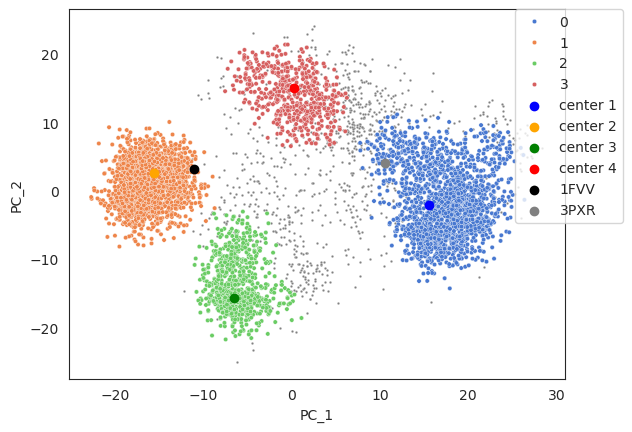

In [63]:
plt.figure()
sns.scatterplot(data=pca_df[pca_df.clust<0], x="PC_1", y="PC_2", color='gray', s=3)
sns.scatterplot(data=pca_df[pca_df.clust>=0], x="PC_1", y="PC_2", hue="clust", s=10,
                palette=sns.color_palette("muted", n_colors=n_clusters_))

plt.scatter(pca_df.PC_1[center_frame[0][1]], pca_df.PC_2[center_frame[0][1]], color='blue', label='center 1')
plt.scatter(pca_df.PC_1[center_frame[1][1]], pca_df.PC_2[center_frame[1][1]], color='orange', label='center 2')
plt.scatter(pca_df.PC_1[center_frame[2][1]], pca_df.PC_2[center_frame[2][1]], color='green', label='center 3')
plt.scatter(pca_df.PC_1[center_frame[3][1]], pca_df.PC_2[center_frame[3][1]], color='red', label='center 4')

plt.scatter(pca_df.PC_1[0], pca_df.PC_2[0], color='black', label='1FVV')
plt.scatter(pca_df.PC_1[1], pca_df.PC_2[1], color='gray', label='3PXR')

plt.legend(bbox_to_anchor=(0.9, 1), loc=2, borderaxespad=0.)


- save each representative structure:

In [64]:
for i in range(n_clusters_):
    os.makedirs('cluster_{}'.format(i+1), exist_ok=True)
    
apo_to_dock = apo_md.select_atoms('not name M*')
holo_to_dock = holo_md.select_atoms('not name M*')
holo_lig_to_dock = holo_lig_md.select_atoms('not name M*')

apo_md.trajectory[center_frame[0][0]]
apo_to_dock.atoms.write("cluster_1/cluster_1.pdb")

holo_md.trajectory[center_frame[1][0]]
holo_to_dock.atoms.write("cluster_2/cluster_2.pdb")

holo_lig_md.trajectory[center_frame[2][0]]
holo_lig_to_dock.atoms.write("cluster_3/cluster_3.pdb")
holo_lig_md.trajectory[center_frame[3][0]]
holo_lig_to_dock.atoms.write("cluster_4/cluster_4.pdb")


/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'chainIDs' Using default value of ''
  warnings.warn("Found no information for attr: '{}'"
/opt/sdv/miniconda3/envs/smurail-mdcourse-25/lib/python3.10/site-packages/MDAnalysis/coordinates/PDB.py:1154: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn("Found no information for attr: '{}'"
/opt/sdv/minico

## Docking with vina:

 - a set of 50 molecules (provide by G Moroy) for docking including 40 decoys (`ligand_0001.pdbqt` to `ligand_0040.pdbqt`) and 10 active molecules (`ligand_0041.pdbqt` to `ligand_0050.pdbqt`).
 - You should also have a directory for each clusters with its pdb in it:

```
.
├── Docking_analysis_Student.ipynb
├── banque
│   ├── ligand_0001.pdbqt
|   ├── ligand_0002.pdbqt
│   .   .................
│   └── ligand_0050.pdbqt
├── cluster_1
│   └── cluster_1.pdb
├── cluster_2
│   └── cluster_2.pdb
├── cluster_3
│   └── cluster_3.pdb
├── cluster_4
│   └── cluster_4.pdb
```

- Create a directory for each PDB (1FVV and 3PXR) and save the **align** protein structures:

```
├── cryst_1FVV
│   └── 1FVV_chain_A.pdb
├── cryst_3PXR
│   └── 3PXR_chain_A.pdb
```


- Use `autodock tools` with command `adt` to convert all structure (`cluster_1.pdb` to `3PXR_chain_A.pdb`) in the `pdbqt` format.

- Create the input files for `vina`, with the `center` and `size` obtain from autodock tools :

<span style='color:red'>Q14:</span>

In [82]:
center_coor = [-26.872, 219.052, 127.433]
size = [42, 32, 30]
num_modes = 20
exhaust = 8

for i in range(n_clusters_):
    with open('cluster_{}/cluster_{}.inp'.format(i+1, i+1), 'w') as f:
        f.write('receptor = cluster_{}.pdbqt \n'.format(i+1))
        f.write('ligand = ../ligand.pdbqt \n')
        f.write('out = docking_{}.pdbqt \n'.format(i+1))
        f.write('log = log_{}.txt \n'.format(i+1))
        f.write('\n')
        f.write('center_x = {:.2f} \n'.format(center_coor[0]))
        f.write('center_y = {:.2f} \n'.format(center_coor[1]))
        f.write('center_z = {:.2f} \n'.format(center_coor[2]))
        f.write('\n')
        f.write('size_x = {} \n'.format(size[0]))
        f.write('size_y = {} \n'.format(size[1]))
        f.write('size_z = {} \n'.format(size[2]))
        f.write('\n')
        f.write('num_modes = {} \n'.format(num_modes))
        f.write('exhaustiveness = {} \n'.format(exhaust))

## Launch Vina

In each directories create a bash script similar to this one:

```
#!/bin/bash

alias vina='/opt/sdv/bin/vina'
shopt -s expand_aliases

for file in ../banque/*.pdbqt; do
	name=`basename $file .pdbqt`
	echo $name
	mkdir -p ${name}
	vina --config cluster_2.inp --ligand $file --out ${name}/out.pdbqt --log ${name}/log.txt
done
```

- Then extract energies using the `extract_first_ener`

In [94]:
def extract_first_ener(file):
    
    with open(file, 'r') as filin:
        for line in filin:

            line_split = line.split()

            if len(line_split) > 0 and line_split[0] == '1':
                return(float(line_split[1]))

extract_first_ener('cluster_1/ligand_0001/log.txt')

-6.8

In [99]:
df = pd.DataFrame(columns=['clust', 'mol', 'ener'])

clust_list = ['cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cryst_1FVV', 'cryst_3PXR']

for clust in clust_list:
    for mol_id in range(1, 51):
        file_name = '{}/ligand_{:04d}/log.txt'.format(clust, mol_id)
        ener = extract_first_ener(file_name)
        #print(clust, mol_id, ener)
        new_row = {'clust':clust, 'mol':mol_id, 'ener':ener}
        df.loc[len(df)] = new_row

In [100]:
df

,clust,mol,ener
0,cluster_1,1,-6.8
1,cluster_1,2,-6.3
2,cluster_1,3,-7.5
3,cluster_1,4,-6.2
4,cluster_1,5,-5.7
...,...,...,...
295,cryst_3PXR,46,-8.5
296,cryst_3PXR,47,-8.0
297,cryst_3PXR,48,-8.1
298,cryst_3PXR,49,-8.0


- add a column for molecule axtivity (active:1 and inactive:0) 

In [101]:
# Create a column `active`

df['active'] = 0
df.loc[df.mol > 40, 'active'] = 1

- use the `sklearn` tool to compute the roc curves:

[0.  0.3 0.4 0.8 0.9 0.9 0.9 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1. ]
[0.  0.1 0.2 0.2 0.4 0.4 0.6 0.6 0.8 0.9 0.9 1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1.  1. ]
[0.  0.  0.1 0.1 0.4 0.4 0.8 0.9 0.9 1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1.  1.  1. ]
[0.  0.1 0.2 0.3 0.5 0.8 0.9 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1.  1. ]
[0.  0.1 0.3 0.5 0.7 0.9 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1. ]
[0.  0.  0.3 0.5 0.7 0.8 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
 1.  1.  1.  1. ]


(-0.01, 0.25)

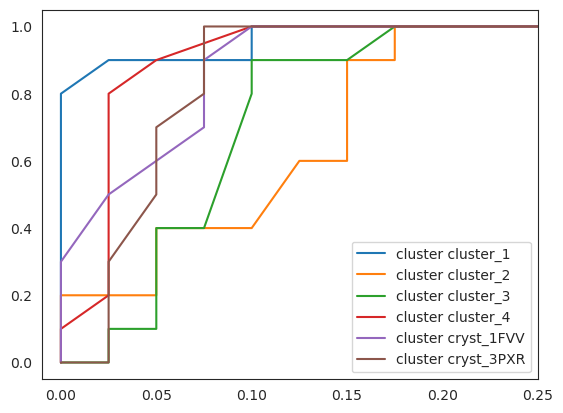

In [102]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_list = []
tpr_list = []

for clust in clust_list:
    df_local = df[df.clust == clust]
    #print(df_local.active, df_local.ener)
    fpr, tpr, thresholds = roc_curve(df_local.active.values, -1*df_local.ener.values)
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    print(tpr)

    plt.plot(fpr, tpr, label='cluster {}'.format(clust))
plt.legend()
plt.xlim([-0.01,0.25])

In [103]:
roc_curve(df_local.active.values, -1*df_local.ener.values)

(array([0.   , 0.025, 0.025, 0.05 , 0.05 , 0.075, 0.075, 0.125, 0.25 ,
        0.325, 0.375, 0.45 , 0.5  , 0.625, 0.65 , 0.725, 0.775, 0.8  ,
        0.85 , 0.875, 0.975, 1.   ]),
 array([0. , 0. , 0.3, 0.5, 0.7, 0.8, 1. , 1. , 1. , 1. , 1. , 1. , 1. ,
        1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. , 1. ]),
 array([inf, 8.8, 8.1, 8. , 7.9, 7.7, 7.6, 7.5, 6.8, 6.7, 6.6, 6.5, 6.4,
        6.3, 6. , 5.9, 5.8, 5.7, 5.6, 5.5, 5.2, 4.9]))

- <span style='color:red'>Q15:</span> Discuss the results of roc curves.
- <span style='color:red'>Q16:</span> Is MD simulation able to improve the docking procedure ? 
- <span style='color:red'>Q17:</span> Discuss the whole protocol and conclude.

## Bonus :

- <span style='color:red'>B1:</span> Compare and present the RMSD of the protein as function of time during the 3 simulations.
- <span style='color:red'>B2:</span> compute the RMSD of ligand as function of time.
- <span style='color:red'>B3:</span> For the first 3 component represent the projection evolution of the 4 first components as function of time colored by simulation